In [1]:
from OptimalBattery import simulate as sim
import numpy as np
import matplotlib.pyplot as plt
import HierarchBayesParcel.evaluation as ev
import torch as pt
import OptimalBattery.util as ut
from numpy.linalg import eigh
from scipy.stats import pearsonr
from Functional_Fusion.dataset import DataSetMDTB
import PcmPy as pcm
import seaborn as sns
import os
import pandas as pd
import pickle
from HierarchBayesParcel.util import indicator
import HierarchBayesParcel.emissions as em
import HierarchBayesParcel.full_model as fm
from IndividualParcellation.evaluate import calc_test_dcbc
from DCBC.utilities import compute_dist
import Functional_Fusion.atlas_map as am

No protocol specified


In [2]:
a,_= am.get_atlas(atlas_str='MNISymC2')

dist = compute_dist(a.world.T, resolution=1)

# MDTB Vs

In [3]:
# mdtb vs based on HBP
model_dir = 'Y:/data/Cerebellum/ProbabilisticParcellationModel/Models'
if not os.path.exists(model_dir):
    model_dir = '/cifs/diedrichsen/data/Cerebellum/ProbabilisticParcellationModel/Models'
    
model_name = f'/Models_03/NettekovenSym32_space-MNISymC2'
fname = model_dir + model_name
with open(fname + '.pickle', 'rb') as file:
        full_model = pickle.load(file)[0]

# load emission model & Vs for mdtb ses-1
mdtb_1_emission = full_model.emissions[0]
mdtb_1_Vs = mdtb_1_emission.V

#make into np array
VL_mdtb = mdtb_1_Vs.detach().numpy()
GL_mdtb = VL_mdtb @ VL_mdtb.T

mdtb_2_emission = full_model.emissions[1]
mdtb_2_Vs = mdtb_2_emission.V

#make into np array
VL_mdtb_2 = mdtb_2_Vs.detach().numpy()
GL_mdtb_2 = VL_mdtb_2 @ VL_mdtb_2.T

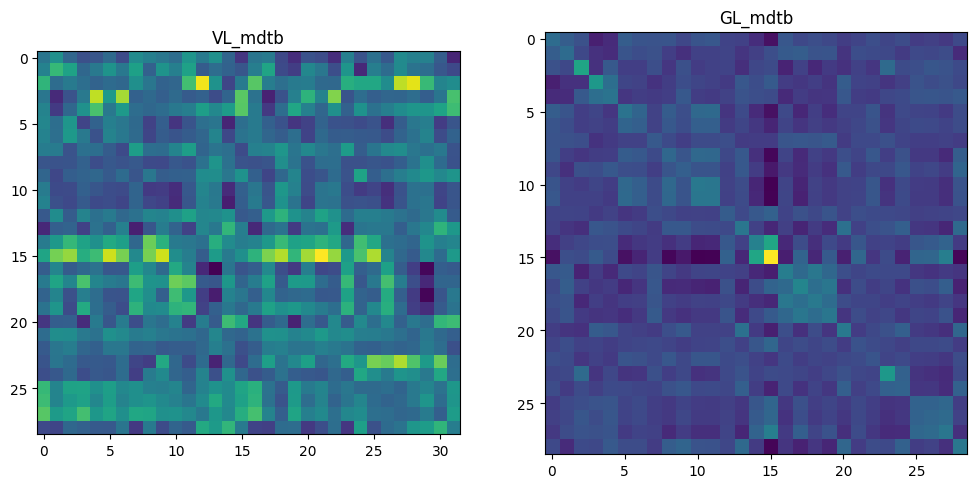

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

ax[0].imshow(VL_mdtb)
ax[0].set_title('VL_mdtb')

ax[1].imshow(GL_mdtb)
ax[1].set_title('GL_mdtb')

plt.show()

In [5]:
cond_vec = np.tile(np.arange(1, 8 + 1), 1)
part_vec = np.repeat(np.arange(1, 1 + 1), 8)

In [6]:
def HBP_u(train_data,cond_vec,part_vec,full_model):
    model = full_model 
    sym_type = 'sym'
    ar_model = model.arrange
    ar_model.logpi = pt.tensor(ar_model.logpi, dtype=pt.get_default_dtype())
    x_matrix = indicator(cond_vec)
    
    
    em_model = em.MixVMF(K=32, P=18290, X=x_matrix, part_vec=part_vec,
                         subject_specific_kappa=False, parcel_specific_kappa=False, 
                         subjects_equal_weight=True)
    
    M_1 = fm.FullMultiModel(arrange=ar_model, emission=[em_model])
    M_1.initialize([train_data])

    M_1, ll,_,U_individual = M_1.fit_em(iter=200, tol=0.01,
                                     fit_arrangement=False,
                                     fit_emission= True,
                                     first_evidence=False)    

    # Get the data-only parcellation
    emloglik = M_1.emissions[0].Estep()
    U_data = pt.softmax(emloglik, dim=1) # get data only parcellation

    return U_data

In [7]:
def evaluate_cos(D,ytrain,Vs,ytest,vtest):
    for i, row in D.iterrows():
        print(i)
        task_subset_indices = row['combination']
        V_subset = Vs[task_subset_indices, :]
        
        # Subtract mean across rows
        V_subset = V_subset - np.mean(V_subset, axis=0)
        
        # Generate the data Y from U_true and V_subset
        y_subset = ytrain[:,task_subset_indices, :]

        # Estimate U_hat using OLS
        U_hat_ols = sim.estimate_Us_ols(y_subset, V_subset)
        # U_hat_NNLS = sim.estimate_Us_NNLS(y_subset, V_subset)    

        # make into tensores
        ytest = pt.tensor(ytest,dtype=pt.float32)
        vtest = pt.tensor(vtest,dtype=pt.float32)
        U_hat_ols = pt.tensor(U_hat_ols,dtype=pt.float32)
        # U_hat_NNLS = pt.tensor(U_hat_NNLS,dtype=pt.float32)
        U_hat_HBP = HBP_u(y_subset,cond_vec,part_vec,full_model)
        

        cos_ols = ev.coserr(ytest,vtest,U_hat_ols).mean().numpy()
        # cos_NNLS = ev.coserr(ytest,vtest,U_hat_NNLS).mean().numpy()
        cos_HBP = ev.coserr(ytest,vtest,U_hat_HBP).mean().numpy()

        Pindiv = pt.argmax(U_hat_HBP, dim=1) + 1
        dcbc_indiv = calc_test_dcbc(Pindiv, ytest, dist)

        D.at[i, 'cos_ols'] = cos_ols
        # D.at[i, 'cos_NNLS'] = cos_NNLS
        D.at[i, 'cos_HBP'] = cos_HBP
        D.at[i, 'dcbc_indiv'] = dcbc_indiv


    return D

In [8]:
MDTB_dataset = DataSetMDTB('/cifs/diedrichsen/data/FunctionalFusion/MDTB')
data_mdtb_s1_All,info_mdtb_1_All  =MDTB_dataset.get_data(space='MNISymC2',ses_id='ses-s1',type='CondAll')
data_mdtb_s1_All[np.isnan(data_mdtb_s1_All)] = 0

In [9]:
MDTB_dataset = DataSetMDTB('/cifs/diedrichsen/data/FunctionalFusion/MDTB')
data_mdtb_s2_All,info_mdtb_2_All  =MDTB_dataset.get_data(space='MNISymC2',ses_id='ses-s2',type='CondAll')
data_mdtb_s2_All[np.isnan(data_mdtb_s2_All)] = 0

In [10]:
D_mdtb = ut.build_combinations(GL_mdtb, strategy='random',n_iter=25,n_tasks=8,seed=1)
D_mdtb = evaluate_cos(D_mdtb, data_mdtb_s1_All,VL_mdtb, data_mdtb_s2_All, VL_mdtb_2)

A_mdtb = D_mdtb[D_mdtb['offset'] == 0.001]

0


/tmp/ipykernel_393066/2901817201.py:5: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  ar_model.logpi = pt.tensor(ar_model.logpi, dtype=pt.get_default_dtype())


Likelihood decreased - terminating on iteration 1
Subject 0:22.4239s
Subject 1:

KeyboardInterrupt: 

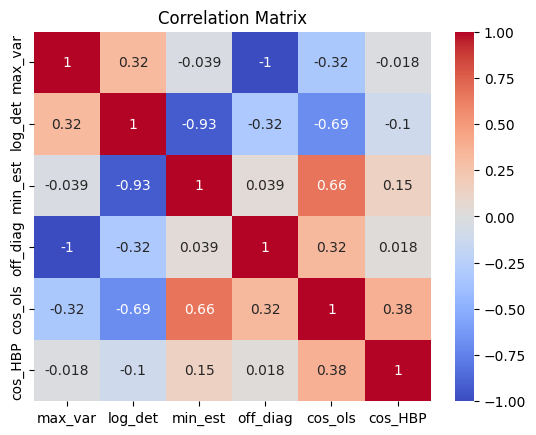

In [24]:
# Correlation heatmap
corr_matrix = A_mdtb[['max_var', 'log_det', 'min_est', 'off_diag','cos_ols','cos_HBP']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()